In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats.mstats import winsorize

Terdapat 4.096 entri di Data Polis dan 4.627 entri di Data Klaim. Ini artinya satu Nomor Polis bisa memiliki lebih dari satu Claim ID

In [2]:
# data load
df = pd.read_csv('Data_Polis.csv')

print("Data Polis")
display(df.head()) 

print("\ndata info")
print(df.info())

# data load 2
df2 = pd.read_csv('Data_Klaim.csv')

print("\nData Klaim")
display(df2.head())

print("\ndata info")
print(df2.info())

Data Polis


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB
None

Data Klaim


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                      4620 n


Missing value Data Polis
Series([], dtype: int64)


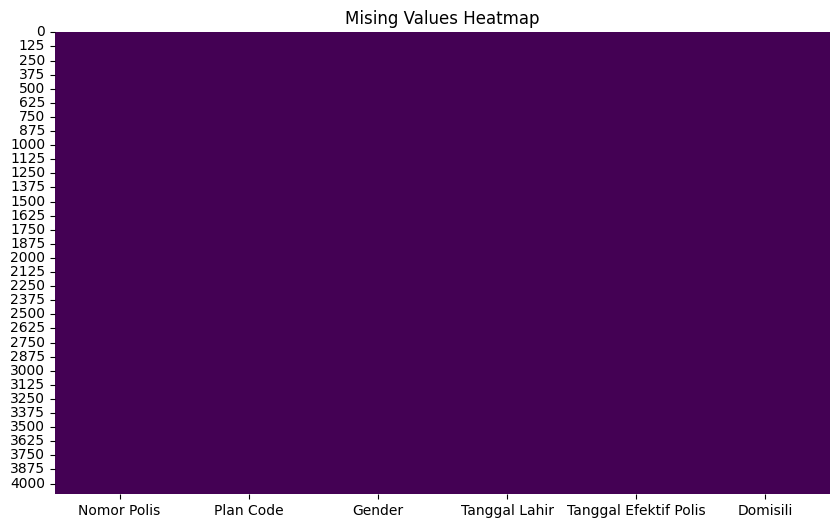


Missing value Data Klaim
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64


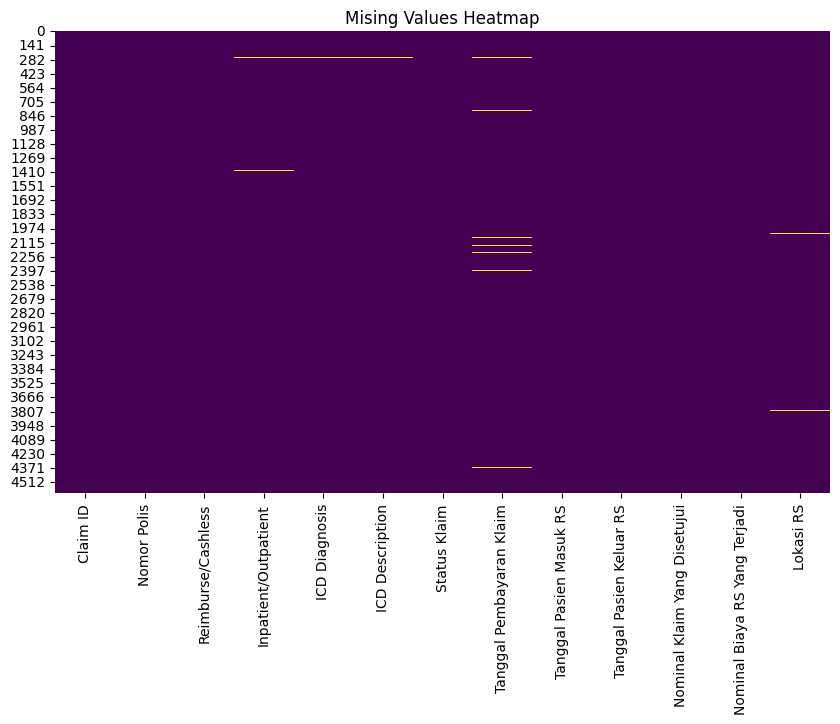

In [3]:
# missing value data polis
print("\nMissing value Data Polis")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

# missing value data klaim
print("\nMissing value Data Klaim")
missing_values = df2.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df2.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

In [4]:
df['Nomor Polis'] = df['Nomor Polis'].str.strip()
df2['Nomor Polis'] = df2['Nomor Polis'].str.strip()

df_final = pd.merge(df, df2, on='Nomor Polis', how='left')

print(f"Jumlah baris df_polis: {len(df)}")
print(f"Jumlah baris df_klaim: {len(df2)}")
print(f"Jumlah baris hasil merge: {len(df_final)}")

display(df_final.head())

Jumlah baris df_polis: 4096
Jumlah baris df_klaim: 4627
Jumlah baris hasil merge: 7513


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,POL-0001,M-003,M,19640811,20140603,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,POL-0002,M-003,M,19710730,20140603,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,POL-0003,M-001,M,19790821,20160808,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia
3,POL-0004,M-003,M,20140724,20160811,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,POL-0005,M-001,F,19810114,20150828,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Data Hasil Merge (Raw) ---


TypeError: '<=' not supported between instances of 'float' and 'str'

In [ ]:
cols_to_zero = ['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']
df_final[cols_to_zero] = df_final[cols_to_zero].fillna(0)

df_final['is_claim'] = df_final['Claim ID'].notnull().astype(int)

cat_cols = [
    'Claim ID', 'Reimburse/Cashless', 'Inpatient/Outpatient', 
    'ICD Diagnosis', 'ICD Description', 'Lokasi RS', 'Status Klaim'
]

for col in cat_cols:
    df_final.loc[df_final['is_claim'] == 0, col] = 'No Claim'
    df_final[col] = df_final[col].fillna('Unknown')

display(df_final.head())

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,is_claim
0,POL-0001,M-003,M,19640811,20140603,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0
1,POL-0002,M-003,M,19710730,20140603,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0
2,POL-0003,M-001,M,19790821,20160808,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia,1
3,POL-0004,M-003,M,20140724,20160811,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0
4,POL-0005,M-001,F,19810114,20150828,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0


Jumlah outlier ditemukan: 1040 baris
Persentase outlier: 13.84%


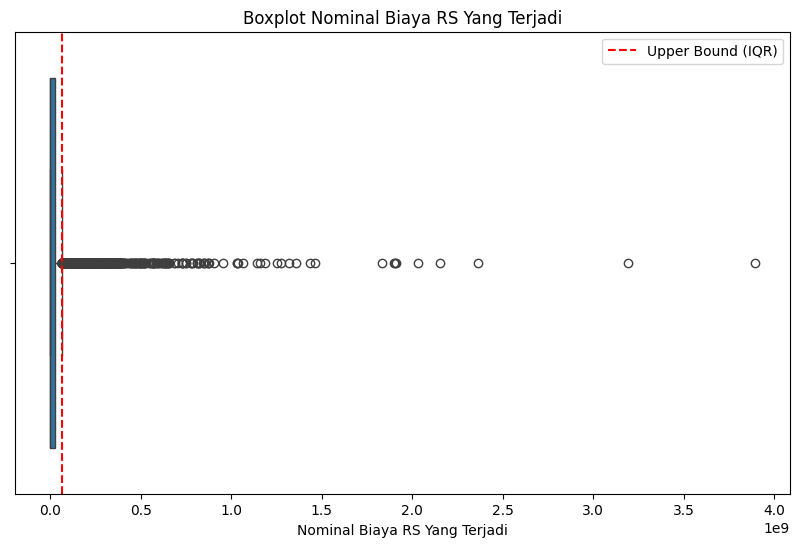

In [ ]:
# Menghitung IQR untuk Nominal Biaya RS
Q1 = df_final['Nominal Biaya RS Yang Terjadi'].quantile(0.25)
Q3 = df_final['Nominal Biaya RS Yang Terjadi'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
outliers = df_final[df_final['Nominal Biaya RS Yang Terjadi'] > upper_bound]

print(f"Jumlah outlier ditemukan: {len(outliers)} baris")
print(f"Persentase outlier: {(len(outliers)/len(df_final))*100:.2f}%")


plt.figure(figsize=(10,6))

sns.boxplot(
    x=df_final['Nominal Biaya RS Yang Terjadi']
)

plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound (IQR)')

plt.title('Boxplot Nominal Biaya RS Yang Terjadi')
plt.xlabel('Nominal Biaya RS Yang Terjadi')
plt.legend()

plt.show()

Distribusi memiliki skewness positif yang tinggi. Mengingat porsi outlier mencapai 13.84%, teknik log-transformation (np.log1p) diterapkan untuk menstabilkan varians bagi pemodelan.

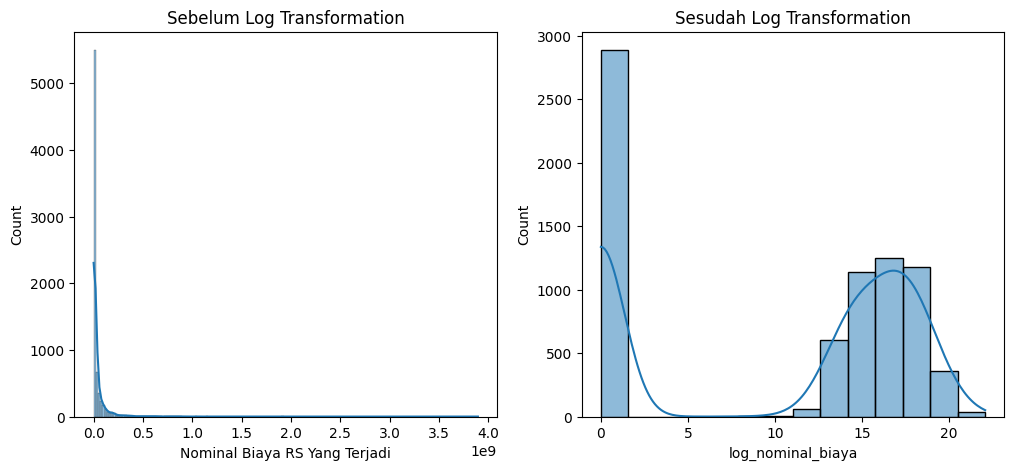

In [ ]:
# Log Transformation
df_final['log_nominal_biaya'] = np.log1p(df_final['Nominal Biaya RS Yang Terjadi'])

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_final['Nominal Biaya RS Yang Terjadi'], kde=True, ax=ax[0]).set_title('Sebelum Log Transformation')
sns.histplot(df_final['log_nominal_biaya'], kde=True, ax=ax[1]).set_title('Sesudah Log Transformation')
plt.show()

In [ ]:
# Sanity check
inkonsisten_biaya = df_final[df_final['Nominal Klaim Yang Disetujui'] > df_final['Nominal Biaya RS Yang Terjadi']]

print(f"Jumlah baris inkonsisten biaya: {len(inkonsisten_biaya)}")

Jumlah baris inkonsisten biaya: 36


In [ ]:
# filter data 
df_consistent = df_final[df_final['Nominal Klaim Yang Disetujui'] <= df_final['Nominal Biaya RS Yang Terjadi']]

# rasio median 
ratios = df_consistent[df_consistent['Nominal Biaya RS Yang Terjadi'] > 0]
median_ratio = (ratios['Nominal Klaim Yang Disetujui'] / ratios['Nominal Biaya RS Yang Terjadi']).median()

mask = df_final['Nominal Klaim Yang Disetujui'] > df_final['Nominal Biaya RS Yang Terjadi']
df_final.loc[mask, 'Nominal Klaim Yang Disetujui'] = df_final.loc[mask, 'Nominal Biaya RS Yang Terjadi'] * median_ratio

print(f"Rasio median yang digunakan: {median_ratio:.4f}")

Rasio median yang digunakan: 0.9879


In [ ]:
df_final['Tanggal Lahir'] = pd.to_datetime(df_final['Tanggal Lahir'], format='%Y%m%d', errors='coerce')
df_final['Tanggal Efektif Polis'] = pd.to_datetime(df_final['Tanggal Efektif Polis'], format='%Y%m%d', errors='coerce')

df_final['Tanggal Pasien Masuk RS'] = pd.to_datetime(df_final['Tanggal Pasien Masuk RS'], errors='coerce')
df_final['Tanggal Pasien Keluar RS'] = pd.to_datetime(df_final['Tanggal Pasien Keluar RS'], errors='coerce')
df_final['Tanggal Pembayaran Klaim'] = pd.to_datetime(df_final['Tanggal Pembayaran Klaim'], errors='coerce')

display(df_final[df_final['is_claim'] == 1][['Nomor Polis', 'Tanggal Pasien Masuk RS']].head())

,Nomor Polis,Tanggal Pasien Masuk RS
2,POL-0003,2024-09-09
5,POL-0006,2024-08-16
6,POL-0006,2024-10-23
10,POL-0010,2024-01-19
11,POL-0010,2024-01-18



Missing value Data final
Tanggal Pembayaran Klaim    2923
Tanggal Pasien Masuk RS     2886
Tanggal Pasien Keluar RS    2886
dtype: int64


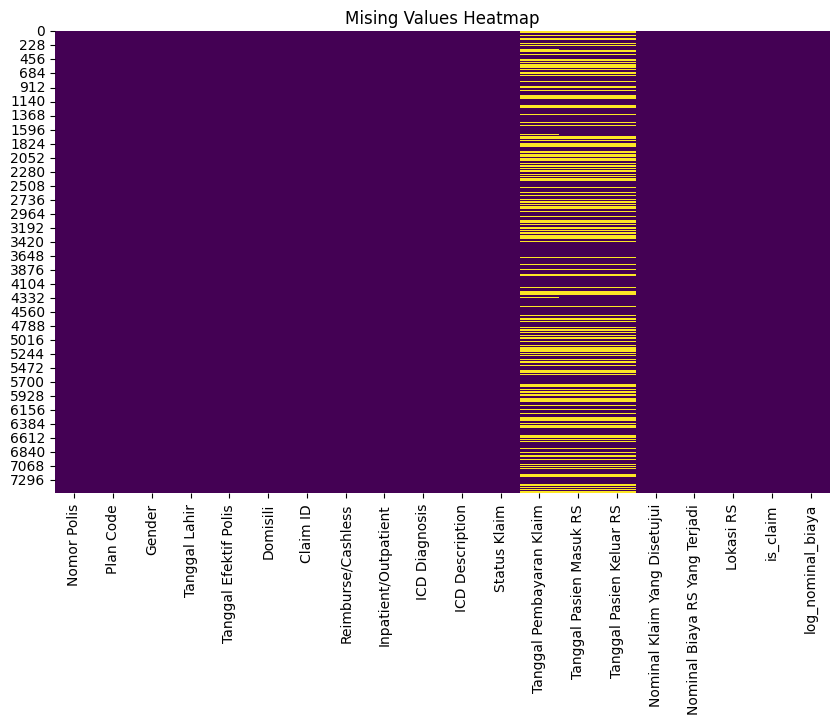

In [ ]:
print("\nMissing value Data final")
missing_values = df_final.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

In [ ]:
# 1. Usia Nasabah
ref_date = df_final['Tanggal Pasien Masuk RS'].max()
df_final['Age'] = (df_final['Tanggal Pasien Masuk RS'].fillna(ref_date) - df_final['Tanggal Lahir']).dt.days // 365

# 2. Tenur Polis 
df_final['Policy_Tenure_Days'] = (df_final['Tanggal Pasien Masuk RS'] - df_final['Tanggal Efektif Polis']).dt.days

# 3. Length of Stay 
df_final['Length_of_Stay'] = (df_final['Tanggal Pasien Keluar RS'] - df_final['Tanggal Pasien Masuk RS']).dt.days

display(df_final[['Age', 'Policy_Tenure_Days', 'Length_of_Stay']].describe())

,Age,Policy_Tenure_Days,Length_of_Stay
count,7513.000000,4627.000000,4627.000000
mean,55.343139,3599.079533,1.264102
std,15.308669,639.473687,2.930572
min,6.000000,2200.000000,0.000000
25%,47.000000,3082.000000,0.000000
50%,57.000000,3591.000000,0.000000
75%,67.000000,4155.000000,1.000000
max,90.000000,4942.000000,54.000000


In [ ]:
# Cek apakah ada data Unknown yang LOS-nya null
check_unknown_null = df_final[
    (df_final['Inpatient/Outpatient'] == 'Unknown') & 
    (df_final['Length_of_Stay'].isnull())
]

if len(check_unknown_null) > 0:
    print(f"Peringatan: Ada {len(check_unknown_null)} data Unknown dengan LOS null!")
else:
    print("Aman: Semua data Unknown memiliki nilai LOS.")

print(df_final[df_final['Inpatient/Outpatient'] == 'Unknown'][['Length_of_Stay', 'log_nominal_biaya']].describe())


Aman: Semua data Unknown memiliki nilai LOS.
       Length_of_Stay  log_nominal_biaya
count       37.000000          37.000000
mean         0.648649          14.858980
std          1.653552           2.308387
min          0.000000           8.917291
25%          0.000000          13.304687
50%          0.000000          14.872934
75%          0.000000          16.309287
max          7.000000          18.460157


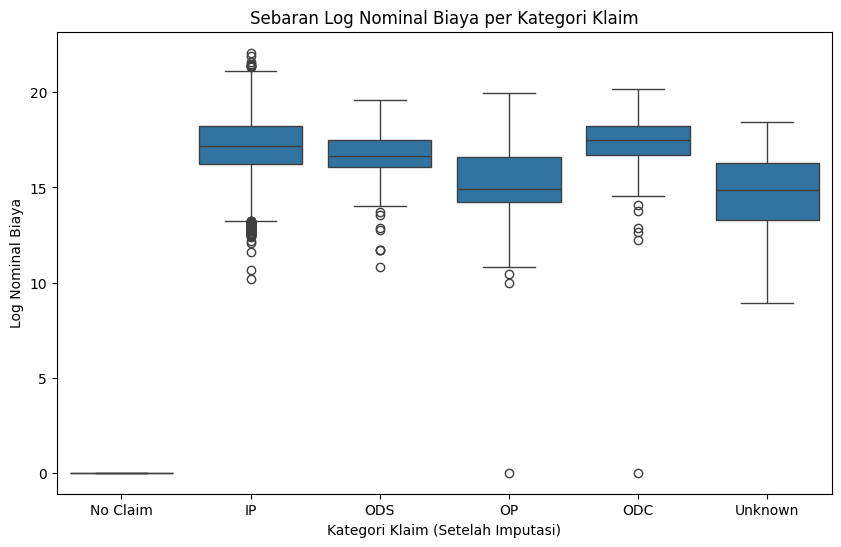

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Inpatient/Outpatient', y='log_nominal_biaya', data=df_final)
plt.title('Sebaran Log Nominal Biaya per Kategori Klaim')
plt.xlabel('Kategori Klaim (Setelah Imputasi)')
plt.ylabel('Log Nominal Biaya')
plt.show()

In [ ]:
def handle_unknown(row):
    if row['Inpatient/Outpatient'] == 'Unknown':
        if row['Length_of_Stay'] > 0:
            return 'IP'
        else:
            return 'OP'
    return row['Inpatient/Outpatient']

df_final['Inpatient/Outpatient'] = df_final.apply(handle_unknown, axis=1)

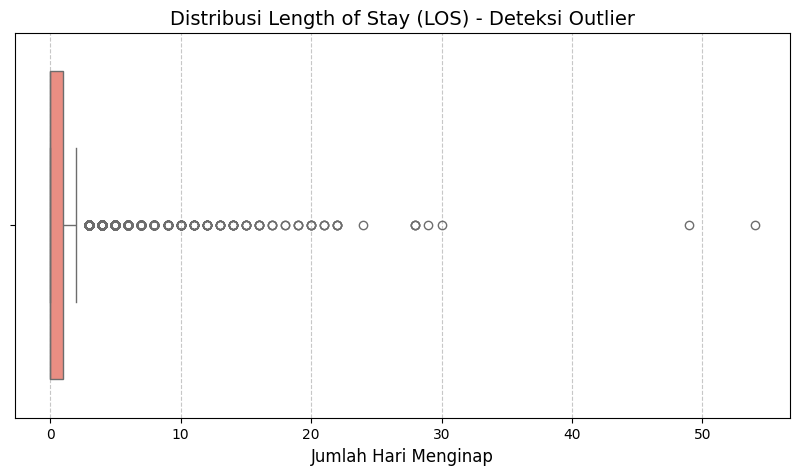

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['Length_of_Stay'], color='salmon')

plt.title('Distribusi Length of Stay (LOS) - Deteksi Outlier', fontsize=14)
plt.xlabel('Jumlah Hari Menginap', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 1. Mencari baris dengan LOS 54 hari
outlier_data = df_final[df_final['Length_of_Stay'] == 54]

# 2. Mencari nilai max log_nominal_biaya di seluruh dataset
max_cost = df_final['log_nominal_biaya'].max()

print("--- Detail Data LOS 54 Hari ---")
display(outlier_data[['Nomor Polis', 'Inpatient/Outpatient', 'Length_of_Stay', 'log_nominal_biaya']])

print(f"\nNilai Maksimum log_nominal_biaya di Dataset: {max_cost:.4f}")

# Cek apakah LOS 54 hari adalah pemegang rekor biaya tertinggi
is_max_cost = outlier_data['log_nominal_biaya'].iloc[0] == max_cost
print(f"Apakah LOS 54 hari memiliki biaya tertinggi? {'YA' if is_max_cost else 'TIDAK'}")

--- Detail Data LOS 54 Hari ---


,Nomor Polis,Inpatient/Outpatient,Length_of_Stay,log_nominal_biaya
1368,POL-0830,IP,54.0,21.10555



Nilai Maksimum log_nominal_biaya di Dataset: 22.0824
Apakah LOS 54 hari memiliki biaya tertinggi? TIDAK


In [ ]:
# Cek detail klaim dengan LOS tertinggi
outlier_extreme = df_final[df_final['Length_of_Stay'] == 54]
print(outlier_extreme[['Nominal Klaim Yang Disetujui', 'ICD Description', 'Inpatient/Outpatient']])

      Nominal Klaim Yang Disetujui  \
1368                  1.411122e+09   

                                        ICD Description Inpatient/Outpatient  
1368  MALIGNANT NEOPLASM, BRONCHUS OR LUNG, UNSPECIFIED                   IP  


In [ ]:
limit_99 = df_final['Length_of_Stay'].quantile(0.99)
print(f"Batas atas wajar (99%): {limit_99} hari")

df_final['LOS_winsorized'] = df_final['Length_of_Stay'].clip(upper=limit_99)

df_final['log_nominal_klaim'] = np.log1p(df_final['Nominal Klaim Yang Disetujui'])

print(f"LOS sebelum: {df_final['Length_of_Stay'].max()} hari")
print(f"LOS sesudah: {df_final['LOS_winsorized'].max()} hari")

Batas atas wajar (99%): 13.0 hari
LOS sebelum: 54.0 hari
LOS sesudah: 13.0 hari


In [ ]:
df_final.head()

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,...,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,is_claim,log_nominal_biaya,Age,Policy_Tenure_Days,Length_of_Stay,LOS_winsorized,log_nominal_klaim
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,...,0.0,0.0,No Claim,0,0.000000,61,NaN,NaN,NaN,0.000000
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,...,0.0,0.0,No Claim,0,0.000000,54,NaN,NaN,NaN,0.000000
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA,C-3535-M,C,IP,S83.2,...,14138163.0,14138163.0,Indonesia,1,16.464388,45,2954.0,1.0,1.0,16.464388
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA,No Claim,No Claim,No Claim,No Claim,...,0.0,0.0,No Claim,0,0.000000,11,NaN,NaN,NaN,0.000000
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA,No Claim,No Claim,No Claim,No Claim,...,0.0,0.0,No Claim,0,0.000000,44,NaN,NaN,NaN,0.000000


In [ ]:
print("Kategori unik di Domisili:")
print(df_final['Domisili'].unique())

print("\nDistribusi tiap kategori:")
print(df_final['Domisili'].value_counts())

Kategori unik di Domisili:
['JAKARTA' 'TANGERANG' 'YOGYAKARTA' 'BANDUNG' 'PALU' 'SORONG' 'MAKASSAR'
 'LAMPUNG' 'BALIKPAPAN' 'SURABAYA' 'SAMARINDA' 'MALANG' 'BLITAR' 'MEDAN'
 'MANADO' 'JEMBER' 'PALEMBANG' 'BALI' 'SEMARANG' 'SOLO' 'KUDUS']

Distribusi tiap kategori:
Domisili
SURABAYA      2824
JAKARTA       2152
TANGERANG      520
MAKASSAR       442
YOGYAKARTA     354
PALEMBANG      299
BALIKPAPAN     246
BANDUNG        244
MANADO          67
JEMBER          57
MEDAN           54
SOLO            54
MALANG          45
SAMARINDA       43
PALU            34
SEMARANG        31
BLITAR          21
BALI            12
SORONG           6
LAMPUNG          5
KUDUS            3
Name: count, dtype: int64


In [ ]:
print("Kategori unik di Lokasi RS:")
print(df_final['Lokasi RS'].unique())

print("\nDistribusi tiap kategori:")
print(df_final['Lokasi RS'].value_counts())

Kategori unik di Lokasi RS:
['No Claim' 'Indonesia' 'Singapore' 'Malaysia' 'Others' 'Overseas'
 'Unknown' 'Taiwan' 'Hong Kong' 'Tiongkok' 'Australia' 'Japan']

Distribusi tiap kategori:
Lokasi RS
Indonesia    3102
No Claim     2886
Singapore    1019
Malaysia      456
Overseas       28
Unknown         7
Others          6
Taiwan          5
Hong Kong       1
Tiongkok        1
Australia       1
Japan           1
Name: count, dtype: int64


In [ ]:
# 1. Tentukan negara utama yang datanya cukup banyak
top_locations = ['Indonesia', 'Singapore', 'Malaysia', 'No Claim']

# 2. Buat kolom baru hasil grouping
def group_lokasi(x):
    if x in top_locations:
        return x
    else:
        # Menggabungkan Overseas, Others, Unknown, Taiwan, Japan, dll.
        return 'OTHER_OVERSEAS'

df_final['Lokasi_RS_Grouped'] = df_final['Lokasi RS'].apply(group_lokasi)

# 3. Cek hasil distribusinya
print("Distribusi Lokasi RS Setelah Grouping:")
print(df_final['Lokasi_RS_Grouped'].value_counts())

Distribusi Lokasi RS Setelah Grouping:
Lokasi_RS_Grouped
Indonesia         3102
No Claim          2886
Singapore         1019
Malaysia           456
OTHER_OVERSEAS      50
Name: count, dtype: int64


In [ ]:
print("Kategori unik di Lokasi RS:")
print(df_final['ICD Description'].unique())

print("\nDistribusi tiap kategori:")
print(df_final['ICD Description'].value_counts())

Kategori unik di Lokasi RS:
['No Claim' 'TEAR OF MENISCUS, CURRENT'
 'INJURY OF MUSCLE(S) AND TENDON(S) OF THE ROTATOR CUFF OF SHOULDER'
 'INFECTION AND INFLAMMATORY REACTION DUE TO OTHER INTERNAL ORTHOPAEDIC PROSTHETIC DEVICES, IMPLANTS AND GRAFTS'
 'POLYP OF STOMACH AND DUODENUM' 'ACUTE APPENDICITIS'
 'Other specified diseases of intestine' 'ILEUS, UNSPECIFIED'
 'SEBORRHOEIC KERATOSIS' 'ATHEROSCLEROTIC HEART DISEASE'
 'OTHER AND UNSPECIFIED ABDOMINAL PAIN' 'ENCEPHALOPATHY, UNSPECIFIED'
 'OTHER GASTROENTERITIS AND COLITIS OF INFECTIOUS AND UNSPECIFIED ORIGIN'
 'FRACTURE OF FIBULA ALONE' 'FRACTURE OF LOWER LEG, INCLUDING ANKLE'
 'OTHER CATARACT' 'CHRONIC ISCHAEMIC HEART DISEASE'
 'GASTRITIS, UNSPECIFIED'
 'Cerebral infarction due to cerebral venous thrombosis, nonpyogenic'
 'CEREBRAL INFARCTION DUE TO CEREBRAL VENOUS THROMBOSIS, NONPYOGENIC'
 'RETINAL DISORDER, UNSPECIFIED' 'Hypertrophy of bone'
 'Epidermal cyst (kista epidermal)' 'Malignant neoplasm of ovari'
 'Malignant neoplasm of o

In [ ]:
def segment_icd(text):
    text = str(text).upper()
    
    if 'NO CLAIM' in text:
        return '0_NO_CLAIM'
    
    # 1. Kanker & Neoplasma (High Severity)
    if any(x in text for x in ['NEOPLASM', 'MALIGNANT', 'LEUKAEMIA', 'MYELOMA', 'CARCINOMA', 'TUMOR', 'BENIGN', 'LEIOMYOMA', 'POLYP']):
        return 'CANCER_NEOPLASM'
    
    # 2. Penyakit Ginjal & Saluran Kemih (High Frequency/Chronic)
    if any(x in text for x in ['RENAL', 'KIDNEY', 'DIALYSIS', 'ESRD', 'CALCULUS', 'URINARY', 'CYSTITIS', 'UROLITHIASIS', 'URETER']):
        return 'KIDNEY_URINARY'
    
    # 3. Jantung & Pembuluh Darah (Critical)
    if any(x in text for x in ['HEART', 'INFARCTION', 'ISCHAEMIC', 'HYPERTENSION', 'STROKE', 'ANGINA', 'CARDIOMYOPATHY', 'ATRIAL', 'ATHEROSCLEROTIC', 'VASCULAR']):
        return 'HEART_CIRCULATORY'
    
    # 4. Mata & Lensa (High Volume Procedure)
    if any(x in text for x in ['CATARACT', 'GLAUCOMA', 'RETINAL', 'EYE', 'LENS', 'PTERYGIUM', 'VISION']):
        return 'EYE_VISION'
    
    # 5. Pencernaan & Lambung (Common Acute)
    if any(x in text for x in ['GASTRITIS', 'APPENDICITIS', 'CHOLELITHIASIS', 'HERNIA', 'GASTROENTERITIS', 'DYSPEPSIA', 'COLITIS', 'INTESTINE', 'STOMACH', 'ABDOMINAL PAIN']):
        return 'DIGESTIVE'
    
    # 6. Infeksi & Virus (Seasonal/Common in Indo)
    if any(x in text for x in ['DENGUE', 'DHF', 'TYPHOID', 'TIFUS', 'FEVER', 'INFECTION', 'VIRAL', 'SEPSIS', 'CORONAVIRUS', 'BACTERIAL']):
        return 'INFECTION_FEVER'
    
    # 7. Pernapasan (Acute)
    if any(x in text for x in ['PNEUMONIA', 'BRONCHITIS', 'ASTHMA', 'NASOPHARYNGITIS', 'RESPIRATORY', 'ISPA', 'COUGH']):
        return 'RESPIRATORY'
    
    # 8. Otot, Tulang & Cedera (Orthopedic/Trauma)
    if any(x in text for x in ['FRACTURE', 'MENISCUS', 'SPRAIN', 'SPONDYLOSIS', 'ARTHRITIS', 'BACK PAIN', 'BONE', 'DISC', 'INJURY', 'CONTUSION']):
        return 'ORTHOPEDIC_TRAUMA'
    
    # 9. Endokrin & Metabolik
    if any(x in text for x in ['DIABETES', 'HYPERLIPIDAEMIA', 'THYROID', 'METABOLISM', 'CHOLESTEROL']):
        return 'ENDOCRINE_METABOLIC'

    if 'UNKNOWN' in text or 'nan' in text:
        return 'UNKNOWN'
        
    return 'OTHERS_SYMPTOMS'

# Eksekusi
df_final['ICD_Grouped'] = df_final['ICD Description'].apply(segment_icd)

# Cek hasil
print(df_final['ICD_Grouped'].value_counts())

ICD_Grouped
0_NO_CLAIM             2886
OTHERS_SYMPTOMS        1217
CANCER_NEOPLASM        1021
KIDNEY_URINARY          630
EYE_VISION              447
DIGESTIVE               436
HEART_CIRCULATORY       319
ORTHOPEDIC_TRAUMA       280
INFECTION_FEVER         153
RESPIRATORY              84
ENDOCRINE_METABOLIC      34
UNKNOWN                   6
Name: count, dtype: int64


C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_17596\912816954.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_claim_only, x='ICD_Grouped', y='log_nominal_biaya', palette='viridis')


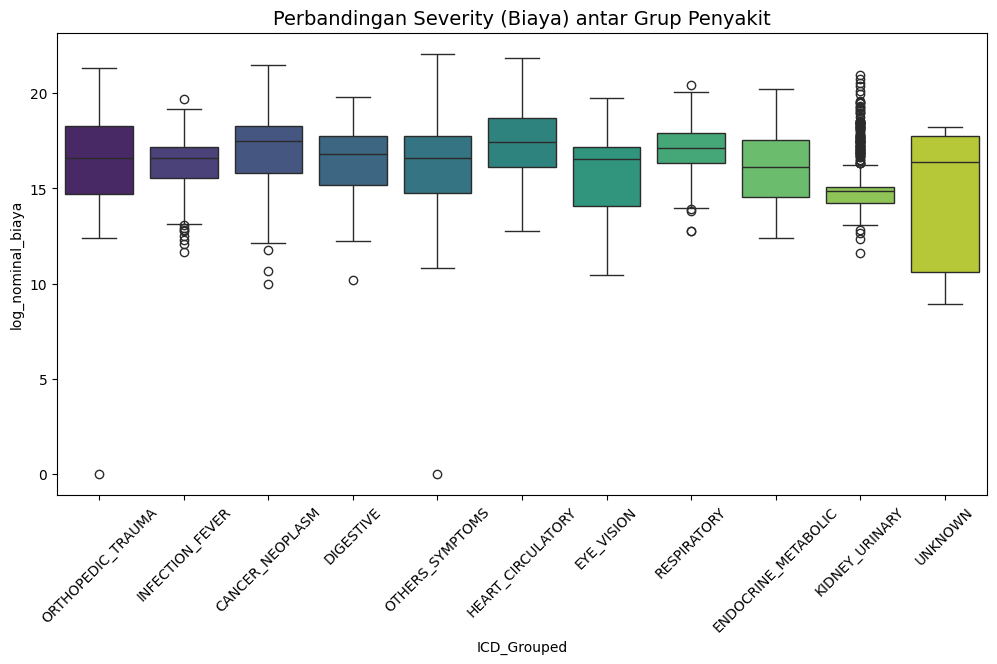

In [ ]:
df_claim_only = df_final[df_final['is_claim'] == 1]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_claim_only, x='ICD_Grouped', y='log_nominal_biaya', palette='viridis')
plt.xticks(rotation=45)
plt.title('Perbandingan Severity (Biaya) antar Grup Penyakit', fontsize=14)
plt.show()


In [ ]:
# Pastikan kolom tanggal sudah dalam format datetime
df_final['Tanggal Pasien Masuk RS'] = pd.to_datetime(df_final['Tanggal Pasien Masuk RS'])

# Buat kolom Year-Month
df_final['YearMonth'] = df_final['Tanggal Pasien Masuk RS'].dt.to_period('M')

# Agregasi data bulanan
df_monthly = df_final.groupby('YearMonth').agg(
    Total_Frequency=('is_claim', 'sum'),
    Average_Severity=('log_nominal_biaya', lambda x: x[x > 0].mean()),
    Total_Claim_Nominal=('Nominal Biaya RS Yang Terjadi', 'sum')
).reset_index()

# Ubah kembali YearMonth ke format datetime agar bisa diplot
df_monthly['YearMonth'] = df_monthly['YearMonth'].dt.to_timestamp()

display(df_monthly.head())

,YearMonth,Total_Frequency,Average_Severity,Total_Claim_Nominal
0,2024-01-01,302,16.524919,2.348332e+10
1,2024-02-01,208,16.446077,1.526124e+10
2,2024-03-01,278,16.512145,1.545641e+10
3,2024-04-01,239,16.121746,1.274456e+10
4,2024-05-01,263,16.146587,1.277547e+10


In [ ]:
# 1. Tentukan Top 8 Domisili berdasarkan data kamu
top_domisili = [
    'SURABAYA', 'JAKARTA', 'TANGERANG', 'MAKASSAR', 
    'YOGYAKARTA', 'PALEMBANG', 'BALIKPAPAN', 'BANDUNG'
]

# 2. Buat kolom baru hasil grouping
df_final['Domisili_Grouped'] = df_final['Domisili'].apply(
    lambda x: x if x in top_domisili else 'OTHERS'
)

# 3. Cek hasil distribusinya
print("Distribusi Domisili Setelah Grouping:")
print(df_final['Domisili_Grouped'].value_counts())

Distribusi Domisili Setelah Grouping:
Domisili_Grouped
SURABAYA      2824
JAKARTA       2152
TANGERANG      520
MAKASSAR       442
OTHERS         432
YOGYAKARTA     354
PALEMBANG      299
BALIKPAPAN     246
BANDUNG        244
Name: count, dtype: int64


In [ ]:
# 1. Pilih kolom yang akan di-encode
cols_to_encode = ['Plan Code', 'Gender', 'Domisili_Grouped', 'Inpatient/Outpatient', 'Lokasi_RS_Grouped', 'ICD_Grouped', 'Reimburse/Cashless']

# 2. One-Hot Encoding
df_model = pd.get_dummies(df_final, columns=cols_to_encode, drop_first=True)

#3. Drop kolom identitas & data mentah yang sudah di-transformasi
cols_to_drop = ['Claim ID', 'Tanggal Lahir', 'Tanggal Efektif Polis', 
                'Tanggal Pasien Keluar RS', 'Tanggal Pembayaran Klaim', 
                'Length_of_Stay', 'ICD Diagnosis', 'ICD Description', 'Domisili', 'Lokasi RS']

df_model = df_model.drop(columns=cols_to_drop)

In [ ]:
df_model.head()

,Nomor Polis,Status Klaim,Tanggal Pasien Masuk RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,is_claim,log_nominal_biaya,Age,Policy_Tenure_Days,LOS_winsorized,...,ICD_Grouped_EYE_VISION,ICD_Grouped_HEART_CIRCULATORY,ICD_Grouped_INFECTION_FEVER,ICD_Grouped_KIDNEY_URINARY,ICD_Grouped_ORTHOPEDIC_TRAUMA,ICD_Grouped_OTHERS_SYMPTOMS,ICD_Grouped_RESPIRATORY,ICD_Grouped_UNKNOWN,Reimburse/Cashless_No Claim,Reimburse/Cashless_R
0,POL-0001,No Claim,NaT,0.0,0.0,0,0.000000,61,NaN,NaN,...,False,False,False,False,False,False,False,False,True,False
1,POL-0002,No Claim,NaT,0.0,0.0,0,0.000000,54,NaN,NaN,...,False,False,False,False,False,False,False,False,True,False
2,POL-0003,PAID,2024-09-09,14138163.0,14138163.0,1,16.464388,45,2954.0,1.0,...,False,False,False,False,True,False,False,False,False,False
3,POL-0004,No Claim,NaT,0.0,0.0,0,0.000000,11,NaN,NaN,...,False,False,False,False,False,False,False,False,True,False
4,POL-0005,No Claim,NaT,0.0,0.0,0,0.000000,44,NaN,NaN,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
print (df_model.columns)

Index(['Nomor Polis', 'Status Klaim', 'Tanggal Pasien Masuk RS',
       'Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi',
       'is_claim', 'log_nominal_biaya', 'Age', 'Policy_Tenure_Days',
       'LOS_winsorized', 'log_nominal_klaim', 'YearMonth', 'Plan Code_M-002',
       'Plan Code_M-003', 'Gender_M', 'Domisili_Grouped_BANDUNG',
       'Domisili_Grouped_JAKARTA', 'Domisili_Grouped_MAKASSAR',
       'Domisili_Grouped_OTHERS', 'Domisili_Grouped_PALEMBANG',
       'Domisili_Grouped_SURABAYA', 'Domisili_Grouped_TANGERANG',
       'Domisili_Grouped_YOGYAKARTA', 'Inpatient/Outpatient_No Claim',
       'Inpatient/Outpatient_ODC', 'Inpatient/Outpatient_ODS',
       'Inpatient/Outpatient_OP', 'Lokasi_RS_Grouped_Malaysia',
       'Lokasi_RS_Grouped_No Claim', 'Lokasi_RS_Grouped_OTHER_OVERSEAS',
       'Lokasi_RS_Grouped_Singapore', 'ICD_Grouped_CANCER_NEOPLASM',
       'ICD_Grouped_DIGESTIVE', 'ICD_Grouped_ENDOCRINE_METABOLIC',
       'ICD_Grouped_EYE_VISION', 'ICD_Grouped_HEA

In [ ]:
print (df_model.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7513 entries, 0 to 7512
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Nomor Polis                       7513 non-null   object        
 1   Status Klaim                      7513 non-null   object        
 2   Tanggal Pasien Masuk RS           4627 non-null   datetime64[ns]
 3   Nominal Klaim Yang Disetujui      7513 non-null   float64       
 4   Nominal Biaya RS Yang Terjadi     7513 non-null   float64       
 5   is_claim                          7513 non-null   int64         
 6   log_nominal_biaya                 7513 non-null   float64       
 7   Age                               7513 non-null   int64         
 8   Policy_Tenure_Days                4627 non-null   float64       
 9   LOS_winsorized                    4627 non-null   float64       
 10  log_nominal_klaim                 7513 non-null 

In [ ]:
df_claims = df_model[df_model['is_claim'] == 1].copy()

df_monthly = df_claims.groupby('YearMonth').agg(
    Frequency=('is_claim', 'count'),
    Total_Nominal=('Nominal Biaya RS Yang Terjadi', 'sum'),
    Avg_Severity_Log=('log_nominal_biaya', 'mean'),
    Avg_LOS=('LOS_winsorized', 'mean')
).reset_index()

df_monthly['YearMonth'] = df_monthly['YearMonth'].dt.to_timestamp()

df_monthly['Total_Nominal_Miliar'] = df_monthly['Total_Nominal'] / 1e9

print("Dataset Bulanan Berhasil Dibuat!")
display(df_monthly.head())

Dataset Bulanan Berhasil Dibuat!


,YearMonth,Frequency,Total_Nominal,Avg_Severity_Log,Avg_LOS,Total_Nominal_Miliar
0,2024-01-01,302,2.348332e+10,16.524919,1.539735,23.483324
1,2024-02-01,208,1.526124e+10,16.446077,1.346154,15.261243
2,2024-03-01,278,1.545641e+10,16.512145,1.413669,15.456405
3,2024-04-01,239,1.274456e+10,16.121746,1.158996,12.744561
4,2024-05-01,263,1.277547e+10,16.146587,1.159696,12.775467


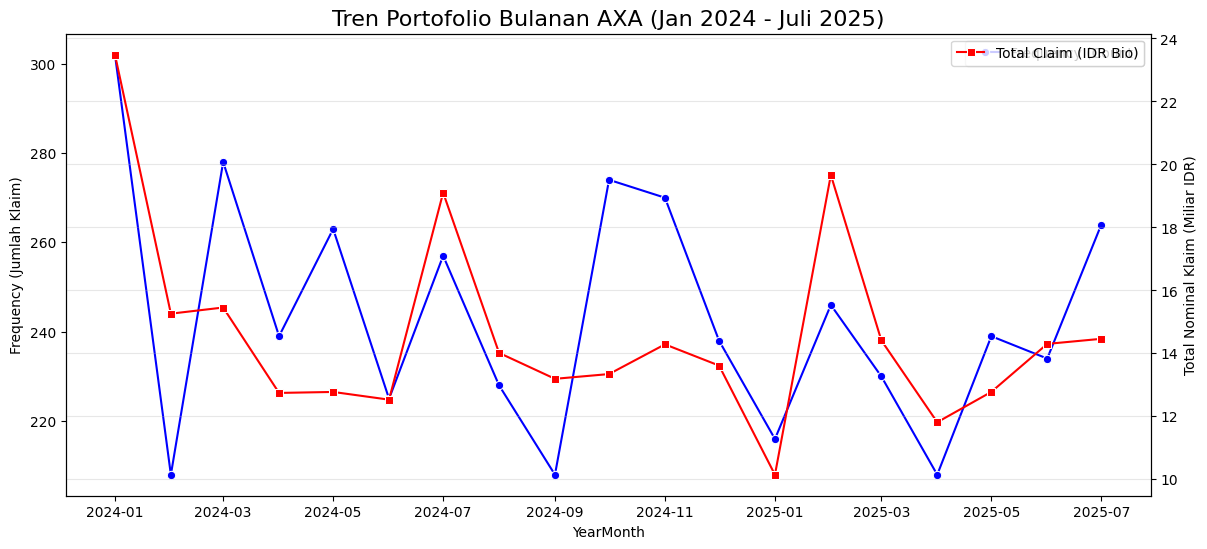

In [ ]:
# Plot Tren Frequency dan Total Nominal
plt.figure(figsize=(14, 6))

# Sumbu kiri untuk Frequency
ax1 = sns.lineplot(data=df_monthly, x='YearMonth', y='Frequency', marker='o', label='Frequency (Count)', color='blue')
ax1.set_ylabel('Frequency (Jumlah Klaim)')

# Sumbu kanan untuk Total Nominal
ax2 = ax1.twinx()
sns.lineplot(data=df_monthly, x='YearMonth', y='Total_Nominal_Miliar', marker='s', label='Total Claim (IDR Bio)', color='red', ax=ax2)
ax2.set_ylabel('Total Nominal Klaim (Miliar IDR)')

plt.title('Tren Portofolio Bulanan AXA (Jan 2024 - Juli 2025)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_17596\2906274419.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_claims_only, x='ICD_Grouped', y='log_nominal_biaya', palette='viridis')


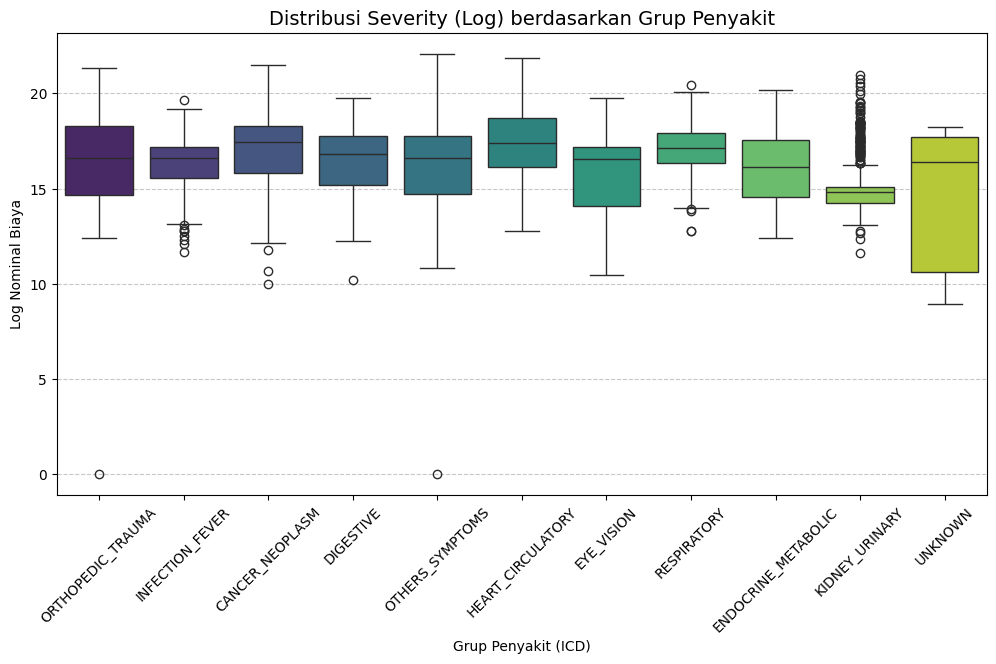

In [ ]:
# Filter data: hanya ambil yang melakukan klaim
df_claims_only = df_final[df_final['is_claim'] == 1].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_claims_only, x='ICD_Grouped', y='log_nominal_biaya', palette='viridis')

plt.title('Distribusi Severity (Log) berdasarkan Grup Penyakit', fontsize=14)
plt.xticks(rotation=45)
plt.xlabel('Grup Penyakit (ICD)')
plt.ylabel('Log Nominal Biaya')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_17596\3219793546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_claims_only, x='Plan Code', y='log_nominal_biaya', palette='magma')


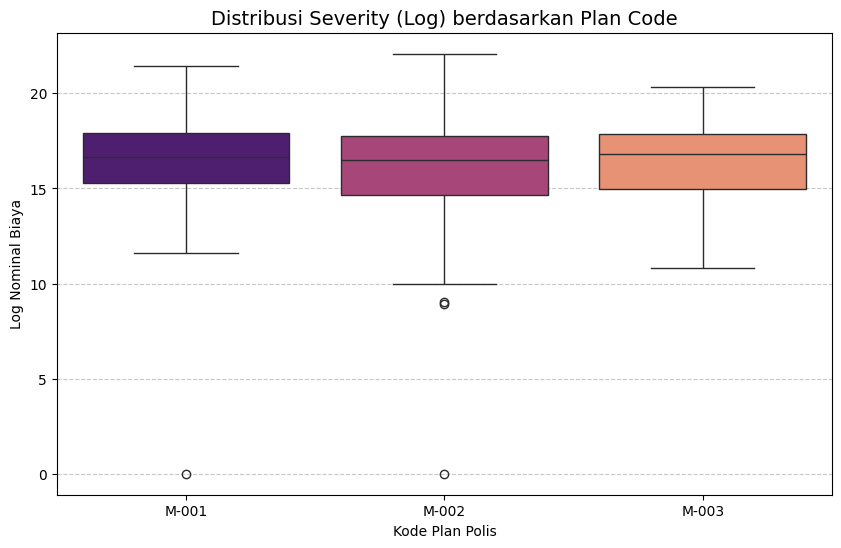

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_claims_only, x='Plan Code', y='log_nominal_biaya', palette='magma')

plt.title('Distribusi Severity (Log) berdasarkan Plan Code', fontsize=14)
plt.xlabel('Kode Plan Polis')
plt.ylabel('Log Nominal Biaya')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
# 1. Pastikan Age_Group dibuat dulu di df_model
def age_segment(age):
    if age <= 17: return '1_CHILD'
    elif age <= 35: return '2_YOUNG_ADULT'
    elif age <= 55: return '3_ADULT'
    else: return '4_SENIOR'

# Buat kolomnya
df_model['Age_Group'] = df_model['Age'].apply(age_segment)

# 2. Baru lakukan One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=['Age_Group'], drop_first=True)

In [ ]:
from scipy.stats import chi2_contingency, kruskal

# 1. Uji Chi-Squared (Untuk Frekuensi/is_claim)
def run_chi2(df, feature):
    contingency_table = pd.crosstab(df[feature], df['is_claim'])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    return p

# 2. Uji Kruskal-Wallis (Untuk Severity/log_biaya - hanya data yang klaim)
def run_kruskal(df, feature):
    df_c = df[df['is_claim'] == 1]
    groups = [group['log_nominal_biaya'].values for name, group in df_c.groupby(feature)]
    stat, p = kruskal(*groups)
    return p

# List fitur asli (sebelum encoding) untuk mempermudah uji
features = ['Plan Code', 'Domisili_Grouped', 'Lokasi_RS_Grouped', 'ICD_Grouped', 'Inpatient/Outpatient']

print("--- HASIL UJI SIGNIFIKANSI (P-VALUE) ---")
for f in features:
    p_freq = run_chi2(df_final, f)
    p_sev = run_kruskal(df_final, f)
    
    print(f"Fitur: {f}")
    print(f"  - Terhadap Frekuensi: {p_freq:.5f} ({'Signifikan' if p_freq < 0.05 else 'Tidak Signifikan'})")
    print(f"  - Terhadap Severitas: {p_sev:.5f} ({'Signifikan' if p_sev < 0.05 else 'Tidak Signifikan'})")
    print("-" * 30)

--- HASIL UJI SIGNIFIKANSI (P-VALUE) ---
Fitur: Plan Code
  - Terhadap Frekuensi: 0.00000 (Signifikan)
  - Terhadap Severitas: 0.00000 (Signifikan)
------------------------------
Fitur: Domisili_Grouped
  - Terhadap Frekuensi: 0.00000 (Signifikan)
  - Terhadap Severitas: 0.00000 (Signifikan)
------------------------------
Fitur: Lokasi_RS_Grouped
  - Terhadap Frekuensi: 0.00000 (Signifikan)
  - Terhadap Severitas: 0.00000 (Signifikan)
------------------------------
Fitur: ICD_Grouped
  - Terhadap Frekuensi: 0.00000 (Signifikan)
  - Terhadap Severitas: 0.00000 (Signifikan)
------------------------------
Fitur: Inpatient/Outpatient
  - Terhadap Frekuensi: 0.00000 (Signifikan)
  - Terhadap Severitas: 0.00000 (Signifikan)
------------------------------


C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_17596\2101458311.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ip_op, x='Inpatient/Outpatient', y='Nominal Biaya RS Yang Terjadi',


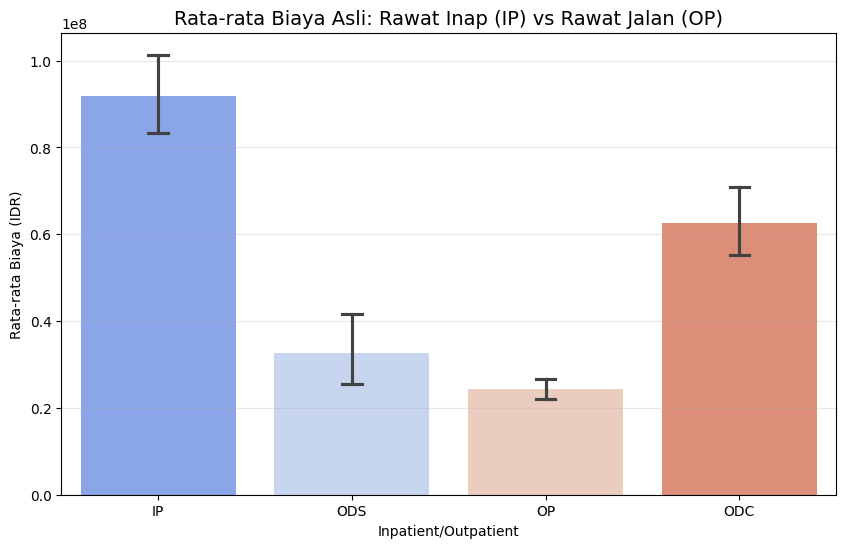

In [ ]:
plt.figure(figsize=(10, 6))
# Filter hanya yang klaim dan bukan 'No Claim'
df_ip_op = df_final[(df_final['is_claim'] == 1) & (df_final['Inpatient/Outpatient'] != 'No Claim')]

sns.barplot(data=df_ip_op, x='Inpatient/Outpatient', y='Nominal Biaya RS Yang Terjadi', 
            estimator='mean', palette='coolwarm', capsize=.1)

plt.title('Rata-rata Biaya Asli: Rawat Inap (IP) vs Rawat Jalan (OP)', fontsize=14)
plt.ylabel('Rata-rata Biaya (IDR)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# 3. Hitung Exposure (Normalisasi durasi polis)
# Rumus: $$Exposure = \frac{Policy\_Tenure\_Days}{max(Policy\_Tenure\_Days)}$$
max_tenure = df_model['Policy_Tenure_Days'].max()
df_model['Exposure'] = df_model['Policy_Tenure_Days'] / max_tenure

# 4. Cleanup: Buang kolom biaya asli agar tidak terjadi Data Leakage
cols_to_drop_final = ['Nominal Biaya RS Yang Terjadi', 'Nominal Klaim Yang Disetujui']
for col in cols_to_drop_final:
    if col in df_model.columns:
        df_model = df_model.drop(columns=col)

display(df_model.head())

,Nomor Polis,Status Klaim,Tanggal Pasien Masuk RS,is_claim,log_nominal_biaya,Age,Policy_Tenure_Days,LOS_winsorized,log_nominal_klaim,YearMonth,...,ICD_Grouped_ORTHOPEDIC_TRAUMA,ICD_Grouped_OTHERS_SYMPTOMS,ICD_Grouped_RESPIRATORY,ICD_Grouped_UNKNOWN,Reimburse/Cashless_No Claim,Reimburse/Cashless_R,Age_Group_2_YOUNG_ADULT,Age_Group_3_ADULT,Age_Group_4_SENIOR,Exposure
0,POL-0001,No Claim,NaT,0,0.000000,61,NaN,NaN,0.000000,NaT,...,False,False,False,False,True,False,False,False,True,NaN
1,POL-0002,No Claim,NaT,0,0.000000,54,NaN,NaN,0.000000,NaT,...,False,False,False,False,True,False,False,True,False,NaN
2,POL-0003,PAID,2024-09-09,1,16.464388,45,2954.0,1.0,16.464388,2024-09,...,True,False,False,False,False,False,False,True,False,0.597734
3,POL-0004,No Claim,NaT,0,0.000000,11,NaN,NaN,0.000000,NaT,...,False,False,False,False,True,False,False,False,False,NaN
4,POL-0005,No Claim,NaT,0,0.000000,44,NaN,NaN,0.000000,NaT,...,False,False,False,False,True,False,False,True,False,NaN


In [ ]:
# 1. LOS (Length of Stay) -> Isi dengan 0
# Logika: Jika tidak klaim/rawat inap, maka lama inapnya adalah 0 hari.
df_model['LOS_winsorized'] = df_model['LOS_winsorized'].fillna(0)

# 2. Policy_Tenure_Days & Exposure
# Fitur ini penting untuk semua nasabah. Jika masih NaN, kita isi dengan median 
# agar tidak merusak distribusi (atau cek kembali perhitungan tenure-mu di awal).
df_model['Policy_Tenure_Days'] = df_model['Policy_Tenure_Days'].fillna(df_model['Policy_Tenure_Days'].median())
df_model['Exposure'] = df_model['Exposure'].fillna(df_model['Exposure'].median())

# 3. Kolom Tanggal (NaT)
# Untuk modeling, kolom datetime/period tidak bisa masuk langsung.
# Kita drop saja karena informasinya sudah kita ekstrak ke fitur lain (Lag/Month).
cols_to_drop_date = ['Tanggal Pasien Masuk RS', 'YearMonth']
for col in cols_to_drop_date:
    if col in df_model.columns:
        df_model = df_model.drop(columns=col)

# 4. Cek ulang sekali lagi
print("Sisa Kolom dengan Missing Value:")
print(df_model.isnull().sum().sum()) # Harusnya 0

Sisa Kolom dengan Missing Value:
0


In [ ]:
# Cek jumlah NaN di tiap kolom (hanya yang > 0)
nan_check = df_model.isnull().sum()
print(nan_check[nan_check > 0])

Series([], dtype: int64)


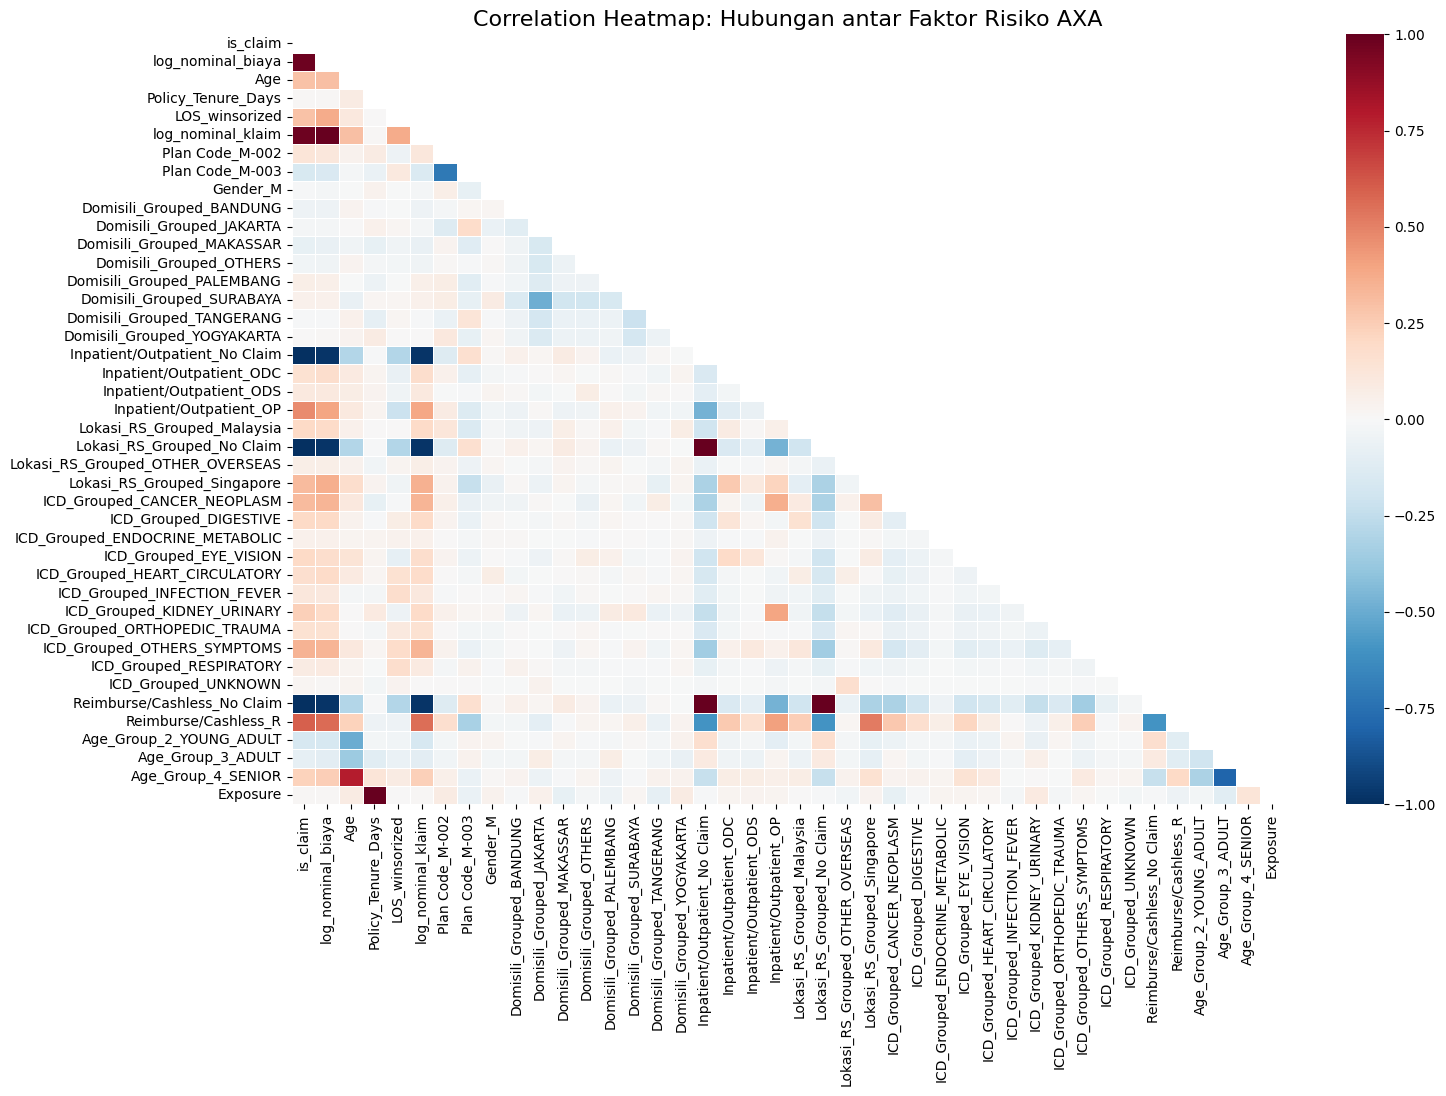

In [ ]:
plt.figure(figsize=(16, 10))

# Pilih kolom yang numerik dan boolean saja
numeric_cols = df_model.select_dtypes(include=[np.number, 'bool']).columns
corr = df_model[numeric_cols].corr()

# Buat mask untuk menutupi bagian atas agar lebih enak dilihat
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation Heatmap: Hubungan antar Faktor Risiko AXA', fontsize=16)
plt.show()

In [ ]:
print (df_model.columns)

Index(['Nomor Polis', 'Status Klaim', 'is_claim', 'log_nominal_biaya', 'Age',
       'Policy_Tenure_Days', 'LOS_winsorized', 'log_nominal_klaim',
       'Plan Code_M-002', 'Plan Code_M-003', 'Gender_M',
       'Domisili_Grouped_BANDUNG', 'Domisili_Grouped_JAKARTA',
       'Domisili_Grouped_MAKASSAR', 'Domisili_Grouped_OTHERS',
       'Domisili_Grouped_PALEMBANG', 'Domisili_Grouped_SURABAYA',
       'Domisili_Grouped_TANGERANG', 'Domisili_Grouped_YOGYAKARTA',
       'Inpatient/Outpatient_No Claim', 'Inpatient/Outpatient_ODC',
       'Inpatient/Outpatient_ODS', 'Inpatient/Outpatient_OP',
       'Lokasi_RS_Grouped_Malaysia', 'Lokasi_RS_Grouped_No Claim',
       'Lokasi_RS_Grouped_OTHER_OVERSEAS', 'Lokasi_RS_Grouped_Singapore',
       'ICD_Grouped_CANCER_NEOPLASM', 'ICD_Grouped_DIGESTIVE',
       'ICD_Grouped_ENDOCRINE_METABOLIC', 'ICD_Grouped_EYE_VISION',
       'ICD_Grouped_HEART_CIRCULATORY', 'ICD_Grouped_INFECTION_FEVER',
       'ICD_Grouped_KIDNEY_URINARY', 'ICD_Grouped_ORTHOPEDIC_TRA

In [ ]:
# Pastikan fitur Exposure dan is_claim sudah ada
# Kita asumsikan ada kolom 'Policy_Number' atau ID unik nasabah. 
# Jika tidak ada, kita gunakan kombinasi fitur unik atau cek kolom ID aslimu.

# 1. Melakukan Groupby berdasarkan Nomor Polis (Ganti 'Policy_Number' sesuai nama kolom ID-mu)
df_policy = df_model.groupby('Nomor Polis').agg(
    Total_Claims=('is_claim', 'sum'),
    Frequency_Rate=('is_claim', 'mean'), # Rasio klaim terhadap transaksi
    Total_Severity_Log=('log_nominal_biaya', 'sum'),
    Avg_Severity_Log=('log_nominal_biaya', 'mean'),
    Max_LOS=('LOS_winsorized', 'max'),
    Avg_Exposure=('Exposure', 'mean'),
    Age=('Age', 'first'),
    Gender=('Gender_M', 'first')
).reset_index()

# 2. Menghitung Annualized Claim Rate (Penting buat laporan!)
# Rumus: Berapa banyak klaim yang dilakukan dibandingkan durasi dia aktif (Exposure)
df_policy['Actual_Claim_Rate'] = df_policy['Total_Claims'] / df_policy['Avg_Exposure']

print("Dataset Level Policy Berhasil Dibuat!")
display(df_policy.sort_values(by='Total_Claims', ascending=False).head())

Dataset Level Policy Berhasil Dibuat!


,Nomor Polis,Total_Claims,Frequency_Rate,Total_Severity_Log,Avg_Severity_Log,Max_LOS,Avg_Exposure,Age,Gender,Actual_Claim_Rate
2077,POL-2078,222,1.0,3357.497467,15.123862,13.0,0.881246,56,True,251.916073
2199,POL-2200,167,1.0,2413.149305,14.449996,1.0,0.640387,50,False,260.779986
2110,POL-2111,91,1.0,1353.105879,14.869295,6.0,0.713859,59,False,127.476193
2328,POL-2329,89,1.0,1399.700495,15.726972,8.0,0.551680,51,True,161.325292
3044,POL-3045,64,1.0,900.598823,14.071857,0.0,0.710084,55,True,90.130201


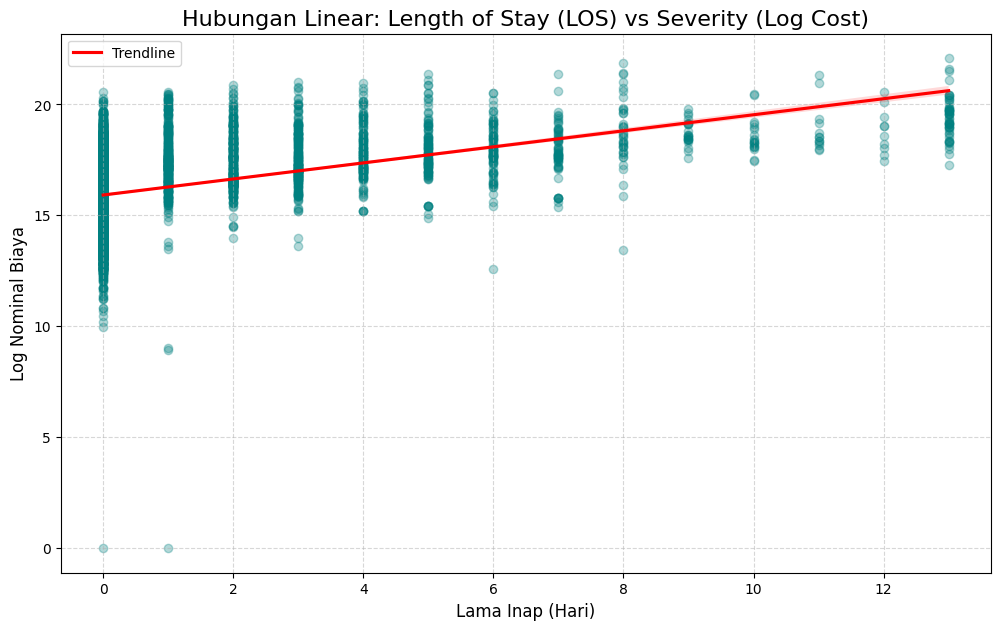

Koefisien Korelasi (Pearson): 0.4446


In [ ]:
# Filter data: Ambil hanya yang melakukan klaim (is_claim == 1)
df_claims_only = df_model[df_model['is_claim'] == 1].copy()

plt.figure(figsize=(12, 7))

# Plotting: LOS vs Log Severity
sns.regplot(data=df_claims_only, x='LOS_winsorized', y='log_nominal_biaya', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red', 'label':'Trendline'})

plt.title('Hubungan Linear: Length of Stay (LOS) vs Severity (Log Cost)', fontsize=16)
plt.xlabel('Lama Inap (Hari)', fontsize=12)
plt.ylabel('Log Nominal Biaya', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

# 2. Hitung Korelasi Pearson untuk Bukti Angka
correlation = df_claims_only['LOS_winsorized'].corr(df_claims_only['log_nominal_biaya'])
print(f"Koefisien Korelasi (Pearson): {correlation:.4f}")